In [267]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import seaborn as sns                       
import matplotlib.pyplot as plt       
import ast   
import pycountry   
%matplotlib inline


In [268]:
df = pd.read_csv("data/filled_jobs.csv")
df.head()

,title,company,location,work_mode,job_type,skills,salary_avg,date_posted,experience_level,education,source,job_url,salary_min,salary_max
0,Data Scientist,"Comscore, Inc.","Pune, Maharashtra, India",onsite,fulltime,"['Linux', 'Python', 'R', 'SQL', 'Spark']",NaN,2026-03-09 00:00:00+00:00,mid-level,Masters in Data Science,datasciencejobs,https://datasciencejobs.com/jobs/data-scientis...,NaN,NaN
1,"Senior Data Scientist, Agentic AI (Insurance U...",Guardian Life,"New York, New York, United States",onsite,fulltime,"['Git', 'PyTorch', 'Python', 'TensorFlow']",157222.5,2026-03-09 00:00:00+00:00,senior,Masters in Data Science,datasciencejobs,https://datasciencejobs.com/jobs/senior-data-s...,118980.0,195465.0
2,Financial Crimes - Senior Data Scientist,KeyBank,"Cleveland, Ohio, United States",onsite,fulltime,"['Python', 'SAS']",134500.0,2026-03-09 00:00:00+00:00,senior,Masters in Data Science,datasciencejobs,https://datasciencejobs.com/jobs/financial-cri...,94000.0,175000.0
3,"Research Scientist – Computer Graphics, Vision...",Eyeline,"Los Angeles, California, United States",onsite,fulltime,['Python'],210000.0,2026-03-09 00:00:00+00:00,mid-level,Masters in Computer Science,datasciencejobs,https://datasciencejobs.com/jobs/research-scie...,100000.0,320000.0
4,Emerging Talent – Computer Vision Engineering ...,Baker Hughes,"Florence, Tuscany, Italy",onsite,fulltime,['Python'],NaN,2026-03-09 00:00:00+00:00,entry-level,Bachelors in Computer Science,datasciencejobs,https://datasciencejobs.com/jobs/emerging-tale...,NaN,NaN


In [269]:
df.dtypes


title                   str
company                 str
location                str
work_mode               str
job_type                str
skills                  str
salary_avg          float64
date_posted             str
experience_level        str
education               str
source                  str
job_url                 str
salary_min          float64
salary_max          float64
dtype: object

In [270]:
def extract_role(title):
    title = title.lower()
    if "data scientist" in title:
        return "Data Scientist"
    elif "data analyst" in title or "analytics" in title:
        return "Data Analyst"
    elif "data engineer" in title:
        return "Data Engineer"
    elif "machine learning" in title or "ml engineer" in title:
        return "ML Engineer"
    elif "research scientist" in title or "research engineer" in title:
        return "Research Scientist"
    elif "business intelligence" in title or "bi " in title:
        return "BI Analyst"
    elif "nlp" in title or "natural language" in title:
        return "NLP Engineer"
    elif "computer vision" in title or "cv engineer" in title:
        return "Computer Vision Engineer"
    elif "ai engineer" in title or "artificial intelligence" in title:
        return "AI Engineer"
    elif "statistician" in title:
        return "Statistician"
    elif "quantitative" in title or "quant " in title:
        return "Quant Analyst"
    elif "data science" in title:
        return "Data Scientist"
    elif "deep learning" in title:
        return "ML Engineer"
    elif "data platform" in title:
        return "Data Engineer"
    else:
        return "Other"

df["role"] = df["title"].apply(extract_role)
df["role"].value_counts()

role
Data Scientist              2295
Other                       1138
ML Engineer                  428
Data Engineer                233
Data Analyst                  58
Computer Vision Engineer      43
AI Engineer                   38
Research Scientist            36
NLP Engineer                  10
Quant Analyst                  3
BI Analyst                     2
Name: count, dtype: int64

In [271]:
# convert skill strings to lists
df["skills"] = df["skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

# explode so each row = one skill
df = df.explode("skills")

# skills being polluted by remoteok
skills_df = df[df["source"] == "datasciencejobs"]

In [272]:
df.head()

,title,company,location,work_mode,job_type,skills,salary_avg,date_posted,experience_level,education,source,job_url,salary_min,salary_max,role
0,Data Scientist,"Comscore, Inc.","Pune, Maharashtra, India",onsite,fulltime,Linux,NaN,2026-03-09 00:00:00+00:00,mid-level,Masters in Data Science,datasciencejobs,https://datasciencejobs.com/jobs/data-scientis...,NaN,NaN,Data Scientist
0,Data Scientist,"Comscore, Inc.","Pune, Maharashtra, India",onsite,fulltime,Python,NaN,2026-03-09 00:00:00+00:00,mid-level,Masters in Data Science,datasciencejobs,https://datasciencejobs.com/jobs/data-scientis...,NaN,NaN,Data Scientist
0,Data Scientist,"Comscore, Inc.","Pune, Maharashtra, India",onsite,fulltime,R,NaN,2026-03-09 00:00:00+00:00,mid-level,Masters in Data Science,datasciencejobs,https://datasciencejobs.com/jobs/data-scientis...,NaN,NaN,Data Scientist
0,Data Scientist,"Comscore, Inc.","Pune, Maharashtra, India",onsite,fulltime,SQL,NaN,2026-03-09 00:00:00+00:00,mid-level,Masters in Data Science,datasciencejobs,https://datasciencejobs.com/jobs/data-scientis...,NaN,NaN,Data Scientist
0,Data Scientist,"Comscore, Inc.","Pune, Maharashtra, India",onsite,fulltime,Spark,NaN,2026-03-09 00:00:00+00:00,mid-level,Masters in Data Science,datasciencejobs,https://datasciencejobs.com/jobs/data-scientis...,NaN,NaN,Data Scientist


In [273]:
df["role"].value_counts()

role
Other                       3130
Data Scientist              2711
ML Engineer                  812
Data Engineer                457
Data Analyst                 113
Computer Vision Engineer     100
AI Engineer                   68
Research Scientist            53
NLP Engineer                  22
Quant Analyst                  7
BI Analyst                     4
Name: count, dtype: int64

In [274]:
df[df["role"] == "Other"]["title"].value_counts().head(20)


title
Senior Software Engineer                      45
Software Engineer                             31
Sales Development Representative              22
Business Development Representative           20
GenAI and LLM Lead                            15
Security Engineer                             15
Customer Success Manager                      15
Account Executive                             15
Engineering Manager                           12
DevOps Engineer                               12
Executive Assistant                           12
Implementation Specialist                     12
QA Engineer                                   12
Technical Project Manager                     12
Product Designer                              12
Finance Expert Crypto                         12
Video Editor                                  12
Account Manager                               11
Senior DevOps Engineer                         9
Implementation Specialist Spanish Speaking     9
Name: count, d

### Number of jobs by company

Text(0.5, 0, 'Company')

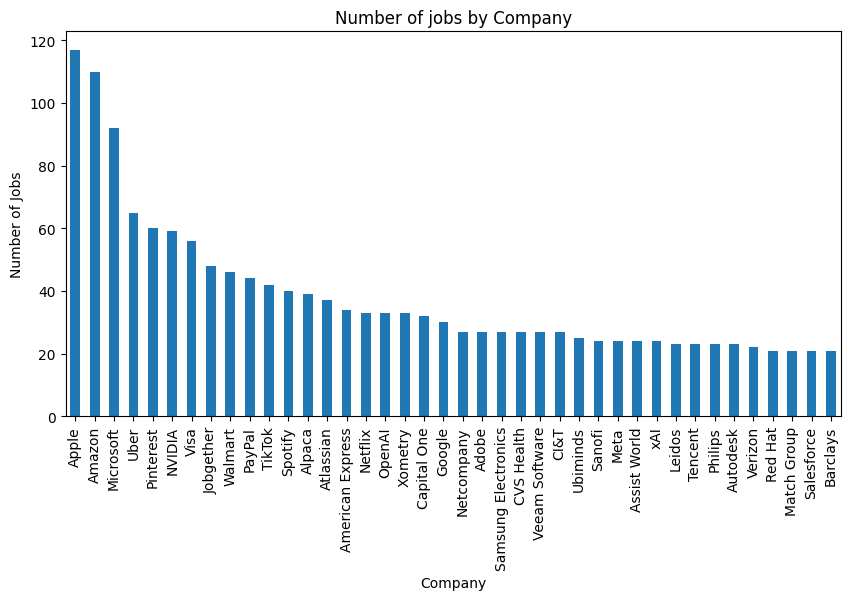

In [275]:
df.company.value_counts().nlargest(40).plot(kind='bar', figsize=(10,5))
plt.title("Number of jobs by Company")
plt.ylabel('Number of Jobs')
plt.xlabel('Company')

### Number of jobs by country


In [276]:
# fix worldwide first
df["location"] = df["location"].apply(
    lambda x: "Worldwide" if any(w in str(x).lower() for w in ["worldwide", "anywhere", "remote"]) else x
)

# extract last part
df["country"] = df["location"].str.split(",").str[-1].str.strip()

# validate with pycountry
def clean_country(val):
    if pd.isna(val) or val == "Worldwide":
        return val
    try:
        return pycountry.countries.lookup(val).name
    except LookupError:
        return None

df["country"] = df["country"].apply(clean_country)



In [277]:
df["country"].value_counts().head(20)

country
United States     2472
Worldwide         1593
India              441
United Kingdom     358
Canada             266
France             107
Singapore           73
Germany             71
Brazil              68
Australia           62
Poland              58
Israel              45
Spain               45
Greece              43
China               42
Netherlands         40
Italy               33
Morocco             28
Malaysia            27
Mexico              27
Name: count, dtype: int64

Text(0.5, 0, 'Country')

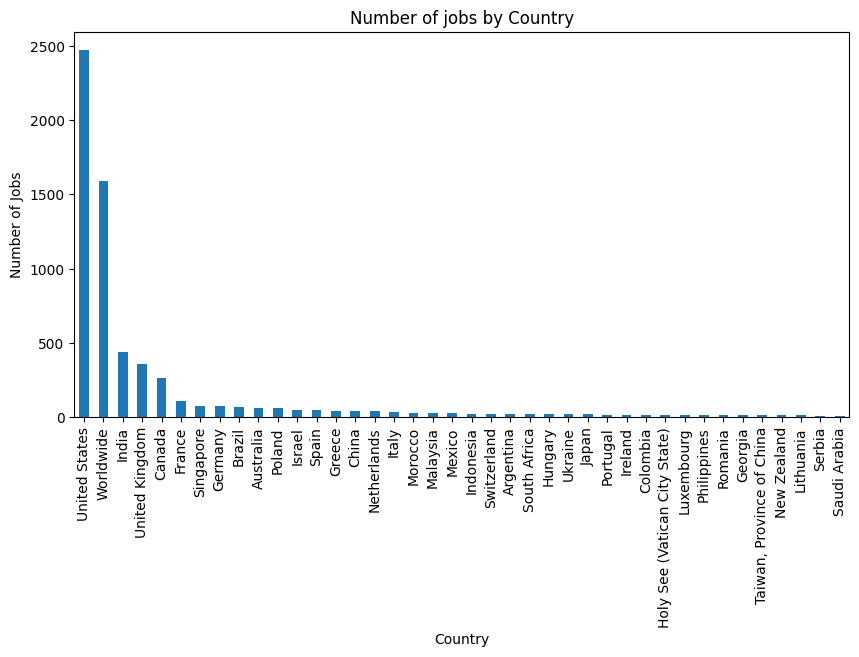

In [278]:
df.country.value_counts().nlargest(40).plot(kind='bar', figsize=(10,5))
plt.title("Number of jobs by Country")
plt.ylabel('Number of Jobs')
plt.xlabel('Country')

### Most in Demand skills



In [279]:
# Top 20 Most in demand

skills_df["skills"].value_counts().head(20)

skills
Python          232
AWS             101
PyTorch          78
SQL              69
Azure            66
GCP              48
C++              43
R                40
TensorFlow       40
Docker           34
Git              32
Databricks       32
Airflow          32
Java             29
NumPy            23
BigQuery         22
Power BI         20
DBT              19
Scikit-Learn     16
Linux            14
Name: count, dtype: int64

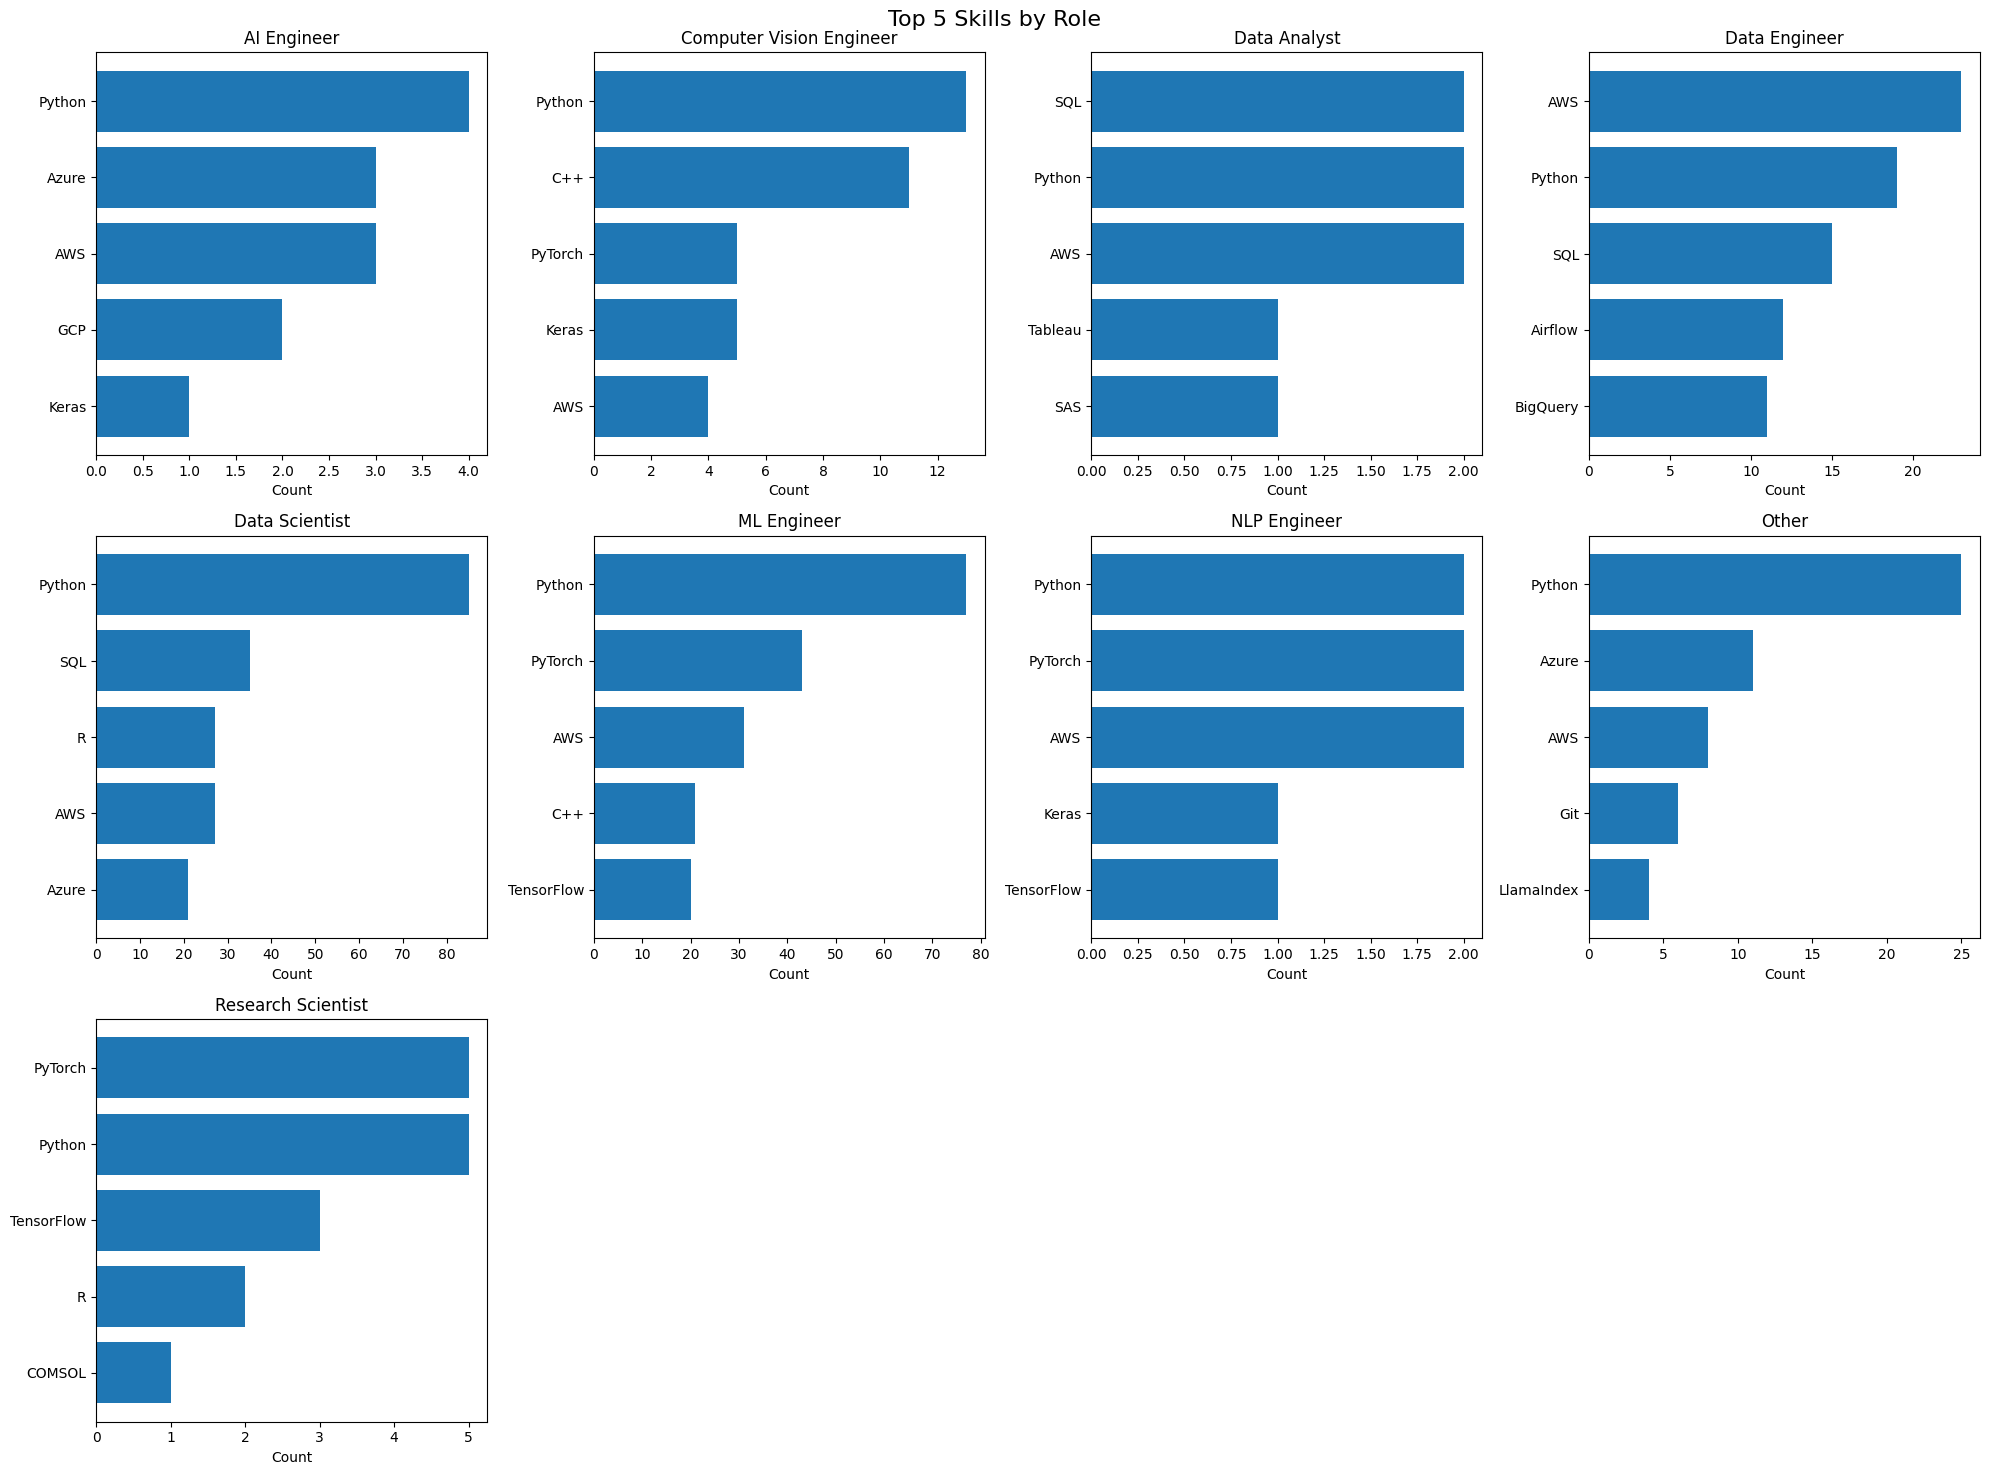

In [280]:
# Top skills by role (datasciencejobs only)
top_skills = skills_df.groupby("role")["skills"].value_counts().groupby(level=0).head(5).reset_index(name="count")

roles = top_skills["role"].unique()
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, role in enumerate(roles):
    role_data = top_skills[top_skills["role"] == role]
    axes[i].barh(role_data["skills"], role_data["count"])
    axes[i].invert_yaxis()
    axes[i].set_title(role)
    axes[i].set_xlabel("Count")

# hide unused subplots
for j in range(len(roles), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Top 5 Skills by Role", fontsize=16)
plt.tight_layout()
plt.show()

### Experience Level Distribution


Text(0.5, 1.0, 'Jobs by Experience Level')

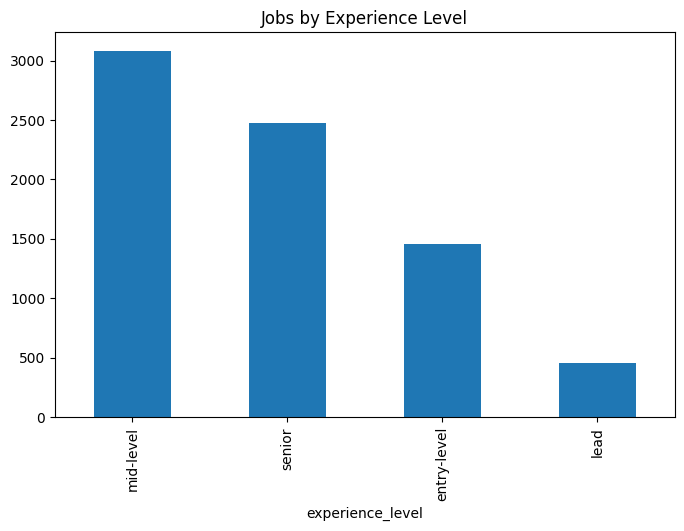

In [281]:
df["experience_level"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Jobs by Experience Level")

### Salary Analysis

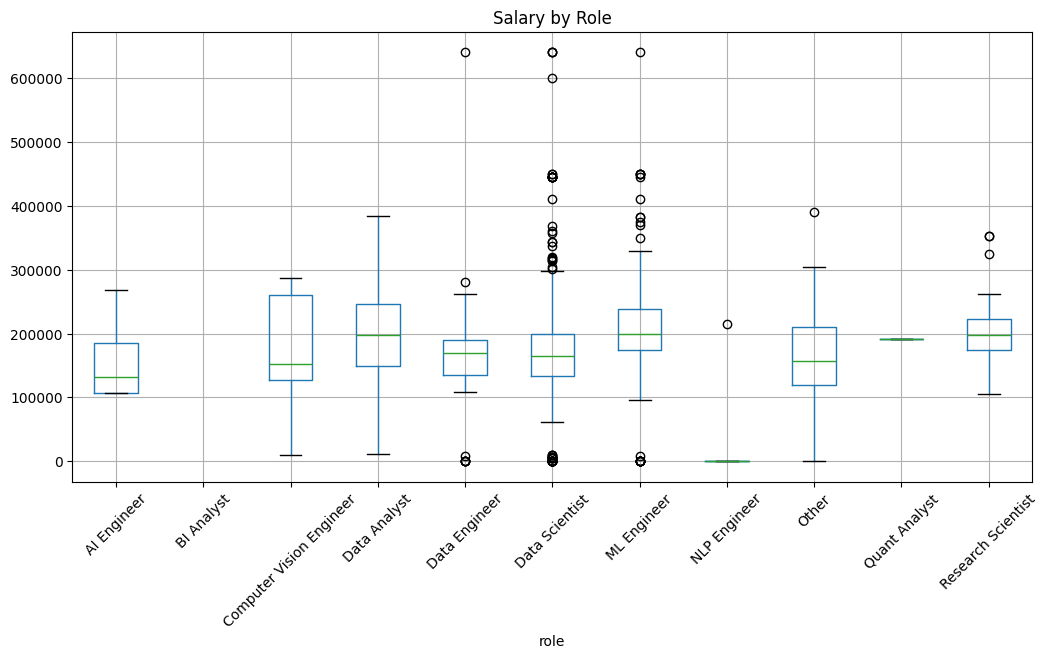

In [282]:
df["salary_avg"].describe()
df.boxplot(column="salary_avg", by="role", figsize=(12,6), rot=45)
plt.title("Salary by Role")
plt.suptitle("")
plt.show()

Text(0.5, 1.0, 'Average Salary by Experience Level')

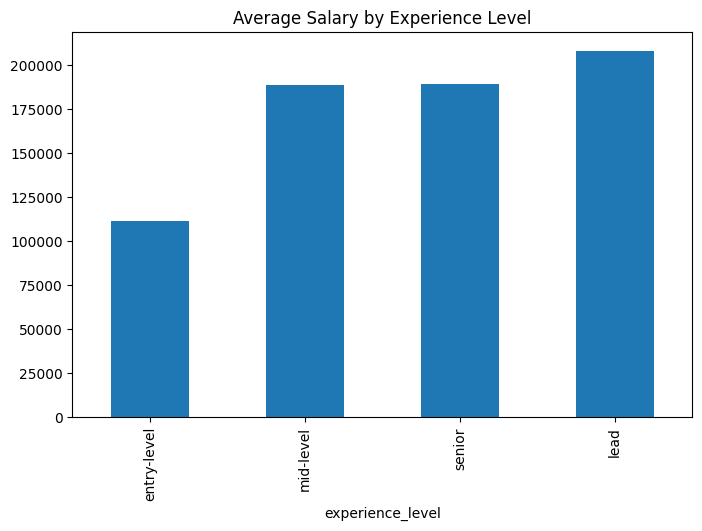

In [283]:
# Salary by experience
df.groupby("experience_level")["salary_avg"].mean().sort_values().plot(kind="bar", figsize=(8,5))
plt.title("Average Salary by Experience Level")

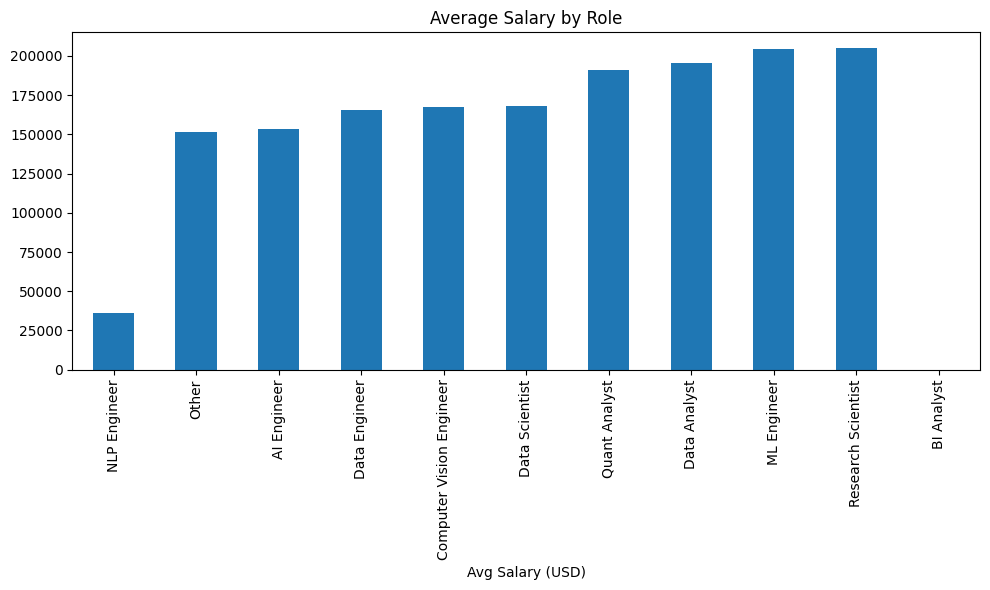

In [284]:
# Salary by role
df.groupby("role")["salary_avg"].mean().sort_values().plot(kind="bar", figsize=(10,6))
plt.title("Average Salary by Role")
plt.xlabel("Avg Salary (USD)")
plt.tight_layout()
plt.show()

### Remote vs Onsite 

Text(0.5, 1.0, 'Remote vs Onsite')

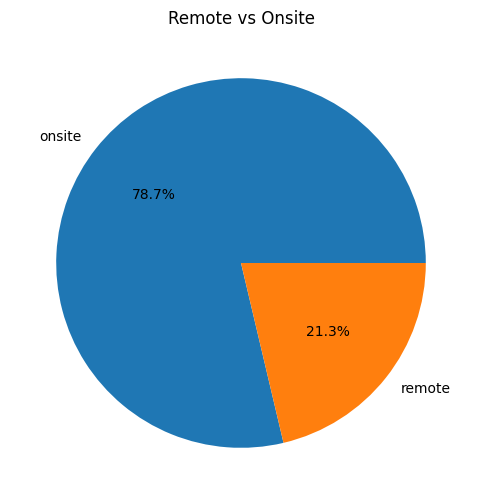

In [285]:
df["work_mode"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Remote vs Onsite")

### Top countries for remote jobs


Text(0.5, 1.0, 'Top Countries for Remote Jobs')

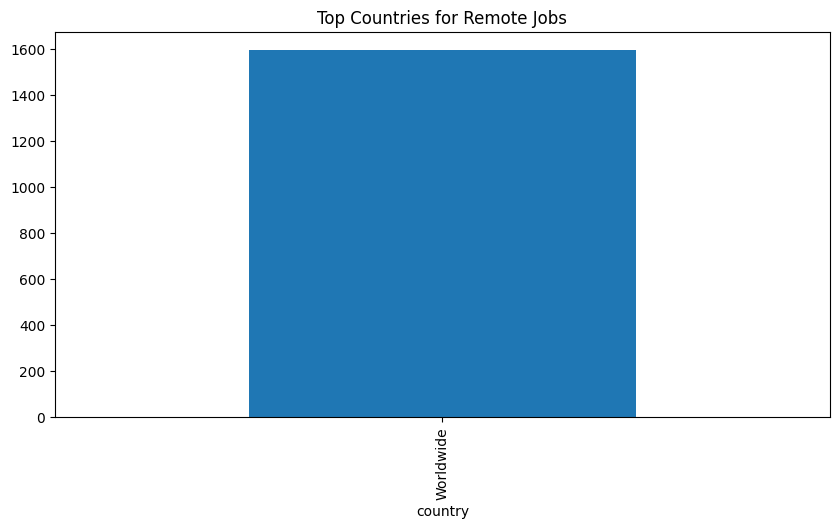

In [286]:
df[df["work_mode"] == "remote"]["country"].value_counts().head(15).plot(kind="bar", figsize=(10,5))
plt.title("Top Countries for Remote Jobs")

### Role Distribution


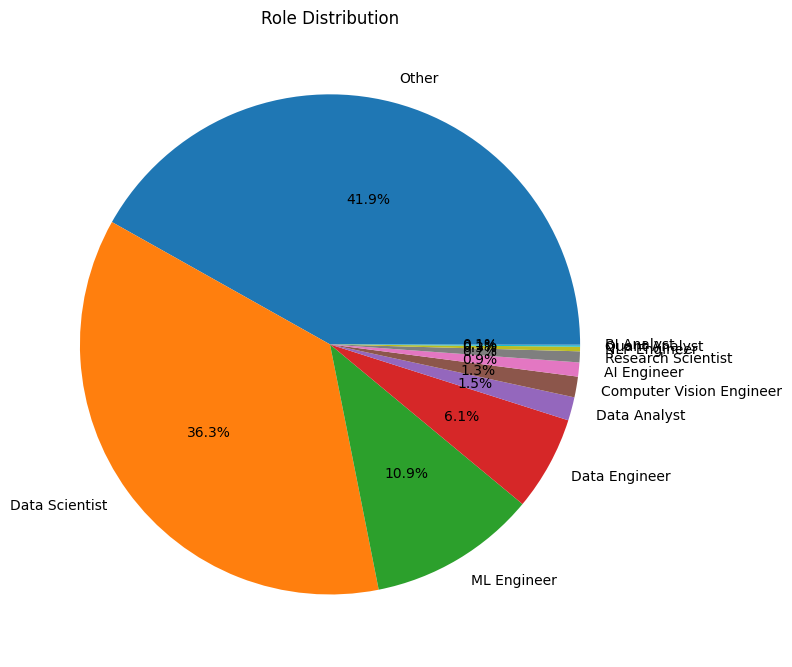

In [287]:
df["role"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(8,8))
plt.title("Role Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("data/clean/tableau_jobs.csv", index=False)